In [2]:
# CARGA DE DATOS #

import pandas as pd
# test comment
# Ruta al archivo de Excel
archivo_excel = './IIYNT-REQ-BD-003.xlsx' #../

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()

# TRANSFORMACIÓN DE DATOS #

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)', 
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:123][desired_columns]
df


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
2,16,0.929,18,8.2,1240,610,NaN,5.37,NaN,NaN,NaN,NaN
3,17,0.47,19,8.3,1630,810,1.8,4.3,NaN,NaN,147,156
4,11.9,0.47,13,8.1,1000,490,18,5.3,NaN,41.2,94,78
5,11.9,0.47,13,8.2,1000,490,18,4.67,NaN,38.9,86,82
6,11.9,0.47,13,8.3,1350,670,0.1,7.01,NaN,30.7,200,117
...,...,...,...,...,...,...,...,...,...,...,...,...
118,12.8,0.57,15.3,8,1110,550,18,4.18,25,5.04,316,66
119,12.8,0.57,15.3,8.1,1080,550,18,4.23,25,5.69,316,66
120,12.8,0.57,15.4,8.4,1050,520,44,1.96,70,113,146,82
121,12.8,0.57,15.4,8.4,1070,530,44,1.67,70,133,146,82


In [3]:

#ver los que tienen valores nulos o no asignados

#df.isnull().sum()
df.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros)

df_sin_nulos=df.copy()
df_sin_nulos.isna().sum()

#Eliminar las filas que tienen valores nulos o no asignados
df_sin_nulos.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true
df_sin_nulos.isna().sum()

Temperatura Ambiental (°C)        0
Humedad                           0
Temperatura de la muestra (°C)    0
pH                                0
CE\n(µS/cm)                       0
STD\n(mg/L)                       0
STS\n(mL sed/L)                   0
OD\n(mg/L)                        0
Nivel (cm)                        0
Turbidez (NTU)                    0
Dureza\n(mg CaCO3/L)              0
Cloruros\n(mg Cl-/L)              0
dtype: int64

In [10]:
def min_max_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    name = list()
    minimums = list()
    maximums = list()
    median = list()
    std = list()
    for i, key in enumerate(dataframe.columns):
        name.append(key)
        minimums.append(dataframe[key].min())
        maximums.append(dataframe[key].max())
        median.append(dataframe[key].median())
        std.append(dataframe[key].std())
        
    return pd.DataFrame(
        {
            'name': name,
            'mins': minimums,
            'maxs': maximums,
            'median': median,
            'std': std
        }
    )
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),10.40,26.000,14.4000,4.380318
1,Humedad,0.36,0.929,0.5600,0.164879
2,Temperatura de la muestra (°C),12.80,28.100,16.9000,2.915339
3,pH,7.20,8.700,8.2000,0.245005
4,CE\n(µS/cm),200.00,1690.000,1290.0000,253.967054
5,STD\n(mg/L),140.00,840.000,635.0000,125.125119
6,STS\n(mL sed/L),0.10,650.000,50.0000,109.747232
7,OD\n(mg/L),0.00,9.120,3.1500,2.097971
8,Nivel (cm),20.00,70.000,39.9375,10.695239
9,Turbidez (NTU),2.68,1000.000,79.6500,245.077765


In [5]:
def normalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return (dataframe - min) / (max - min)

def denormalize(dataframe: pd.DataFrame, min: float, max: float) -> pd.DataFrame:
    return dataframe * (max - min) + min


def normalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = normalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = normalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = normalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = normalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = normalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = normalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = normalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = normalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = normalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = normalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = normalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df

def denormalizer(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    df['Temperatura Ambiental (°C)']                = denormalize(df['Temperatura Ambiental (°C)'],       min=0, max=40)
    df['Humedad'] = df['Humedad']
    df['Temperatura de la muestra (°C)']            = denormalize(df['Temperatura de la muestra (°C)'],   min=0, max=40)
    df['pH']                                        = denormalize(df['pH'],                               min=6, max=10)
    df['CE\n(µS/cm)']                               = denormalize(df['CE\n(µS/cm)'],                      min=100, max=2000)
    df['STD\n(mg/L)']                               = denormalize(df['STD\n(mg/L)'],                      min=100, max=1000)
    df['STS\n(mL sed/L)']                           = denormalize(df['STS\n(mL sed/L)'],                  min=0, max=1000)
    df['OD\n(mg/L)']                                = denormalize(df['OD\n(mg/L)'],                       min=0, max=10)
    df['Nivel (cm)']                                = denormalize(df['Nivel (cm)'],                       min=0, max=100)
    df['Turbidez (NTU)']                            = denormalize(df['Turbidez (NTU)'],                   min=0, max=1000)
    df['Dureza\n(mg CaCO3/L)']                      = denormalize(df['Dureza\n(mg CaCO3/L)'],             min=50, max=500)
    df['Cloruros\n(mg Cl-/L)']                      = denormalize(df['Cloruros\n(mg Cl-/L)'],             min=0, max=200)    
    return df




In [81]:
from keras.layers import Input, Dense
from keras.activations import sigmoid, tanh
from keras.models import Model
import numpy as np
from tensorflow.keras.callbacks import TensorBoard
import shutil
try:
    shutil.rmtree('./.logs')
except FileNotFoundError:
    pass
os.mkdir('./.logs')
vector_size = len(df_sin_nulos.columns)
dataset = np.array(
    normalizer(df_sin_nulos).astype(np.float16)
)
encoded_size = 2

input_layer = Input(shape=(vector_size, )) 

x = Dense(2, activation=sigmoid)(input_layer)
x = Dense(2, activation=sigmoid)(x)

encoded = Dense(encoded_size, activation=tanh)(x)
x = Dense(2, activation=sigmoid)(encoded)
x = Dense(2, activation=sigmoid)(x)
output = Dense(vector_size, activation=sigmoid)(x)

autoencoder = Model(input_layer, output) # creo un modelo a partir de lo definido arriba
autoencoder.compile(optimizer='adam', loss='mse') # se compila el modelo
autoencoder.summary() # se imprime un resumen


Model: "model_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 12)]              0         
                                                                 
 dense_48 (Dense)            (None, 2)                 26        
                                                                 
 dense_49 (Dense)            (None, 2)                 6         
                                                                 
 dense_50 (Dense)            (None, 2)                 6         
                                                                 
 dense_51 (Dense)            (None, 2)                 6         
                                                                 
 dense_52 (Dense)            (None, 2)                 6         
                                                                 
 dense_53 (Dense)            (None, 12)                36 

In [82]:

tensorboard = TensorBoard(log_dir='./.logs') #creo instancia para guardar
epochs = 40000 # cantidad de veces a entranar o pasos para realizar el descenso del gradiente
autoencoder.fit(
    x=dataset,
    y=dataset,
    epochs=epochs,
    batch_size=len(dataset), #tamaño del bloque de entrenamiento
    shuffle=True,
    verbose=0, # que no envie salidas
    callbacks=[tensorboard]
    
)
    


In [83]:
generator = Model(encoded, output) #va del vector de clasificacion hasta la salida
generator.summary()

Model: "model_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_18 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_51 (Dense)            (None, 2)                 6         
                                                                 
 dense_52 (Dense)            (None, 2)                 6         
                                                                 
 dense_53 (Dense)            (None, 12)                36        
                                                                 
Total params: 48 (192.00 Byte)
Trainable params: 48 (192.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [84]:
encoder = Model(input_layer, encoded) #va desde el input a los datos codificados o clasificador
encoder.summary()

Model: "model_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 12)]              0         
                                                                 
 dense_48 (Dense)            (None, 2)                 26        
                                                                 
 dense_49 (Dense)            (None, 2)                 6         
                                                                 
 dense_50 (Dense)            (None, 2)                 6         
                                                                 
Total params: 38 (152.00 Byte)
Trainable params: 38 (152.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [85]:
amount = 500 #cantidad de predicciones
generated = np.zeros(shape=(amount, vector_size))
params = np.random.rand(amount, encoded_size)
generated = generator.predict(params)
gen_df = pd.DataFrame(generated)
gen_df.columns = df_sin_nulos.columns
gen_df = denormalizer(gen_df)
gen_df


16/16 [==============================] - 0s 876us/step


,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
0,23.038807,0.560944,19.877609,7.312483,702.117249,353.127075,39.575432,0.000007,22.004105,994.031982,142.598175,33.447918
1,15.746700,0.580175,17.138990,8.189229,1117.894287,549.623901,13.455687,2.896365,38.512936,87.558586,173.448151,83.419006
2,16.350197,0.577762,17.377098,8.110901,1069.376953,525.920166,13.945439,1.162432,36.728207,153.661758,170.552856,76.909241
3,22.786806,0.498804,20.407116,7.227419,221.234909,145.752182,0.424353,0.000013,13.228531,993.880188,141.191254,4.746869
4,15.661750,0.524003,17.662575,8.083321,416.798431,225.671738,0.222406,3.575504,26.116096,97.846191,171.242828,18.746525
...,...,...,...,...,...,...,...,...,...,...,...,...
495,15.865998,0.526110,17.715197,8.062599,431.967133,232.154724,0.278422,2.730908,26.197456,117.608253,170.397125,19.697416
496,16.675413,0.518161,18.081352,7.947845,361.928589,202.676849,0.209068,0.774512,23.419090,241.141495,166.395172,14.426686
497,15.714151,0.517302,17.747078,8.063098,365.258759,203.967163,0.139895,3.389683,24.734959,105.135910,170.695740,15.135219
498,16.858828,0.517164,18.155993,7.923719,353.331024,199.109787,0.207499,0.564617,22.966309,278.027679,165.543381,13.779184


In [86]:
min_max_info(df_sin_nulos)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),10.40,26.000,14.4000,4.380318
1,Humedad,0.36,0.929,0.5600,0.164879
2,Temperatura de la muestra (°C),12.80,28.100,16.9000,2.915339
3,pH,7.20,8.700,8.2000,0.245005
4,CE\n(µS/cm),200.00,1690.000,1290.0000,253.967054
5,STD\n(mg/L),140.00,840.000,635.0000,125.125119
6,STS\n(mL sed/L),0.10,650.000,50.0000,109.747232
7,OD\n(mg/L),0.00,9.120,3.1500,2.097971
8,Nivel (cm),20.00,70.000,39.9375,10.695239
9,Turbidez (NTU),2.68,1000.000,79.6500,245.077765


In [87]:
min_max_info(gen_df)

,name,mins,maxs,median,std
0,Temperatura Ambiental (°C),15.326829,23.215332,15.725949,2.568269
1,Humedad,0.492637,0.591138,0.516165,0.015116
2,Temperatura de la muestra (°C),16.958755,20.457085,17.765757,0.947003
3,pH,7.207491,8.243998,8.058620,0.302234
4,CE\n(µS/cm),204.799713,1282.231812,356.702271,145.953003
5,STD\n(mg/L),139.236893,631.673889,200.398895,64.766754
6,STS\n(mL sed/L),0.125131,89.222763,0.159219,5.564470
7,OD\n(mg/L),0.000005,4.822734,3.348069,1.525054
8,Nivel (cm),12.994252,41.604084,24.451675,4.841419
9,Turbidez (NTU),60.098801,995.725586,106.827354,357.176270


In [88]:
colors = encoder.predict(dataset)
colored_dataset = df_sin_nulos.copy() #copio el dataset original y lo coloreo con el clsificador (encoder)



def color_row(row, color_vector):
    color_rgb = tuple((color_vector*255).astype(np.int16))
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_rgb[0], color_rgb[1], 255)
    return [f'background-color: {color_hex};' for _ in row.index]

# Create an iterator for the colors
color_iterator = iter(colors)

# Apply colors to each row
styled_df = colored_dataset.style.apply(lambda row: color_row(row, next(color_iterator)), axis=1)
styled_df.to_excel("colored_dataset.xlsx", engine='openpyxl')


4/4 [==============================] - 0s 2ms/step


ValueError: Unexpected color #-1f-3eff

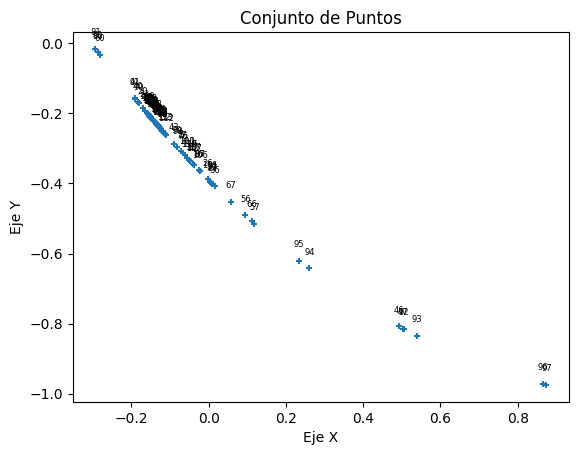

In [89]:
import matplotlib.pyplot as plt


# Dibujamos los puntos
plt.scatter(colors.T[0], colors.T[1], s=20, marker='+')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjunto de Puntos')

# Añadimos índices a cada punto
for i, (xi, yi) in enumerate(colors):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)

plt.show()
